<a href="https://colab.research.google.com/github/fandris03/ResNet-project/blob/main/ResNet_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. ResNet - CIFAR-10

##Setup

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torch.optim as optim
from torch.utils.data import DataLoader
import torch.nn.utils.prune as prune
import matplotlib.pyplot as plt
import numpy as np
import datetime as dt
from zoneinfo import ZoneInfo
from itertools import cycle
from google.colab import drive
import copy


device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")


Using cuda device


In [2]:
drive.mount('/content/drive', force_remount=True)
data_root = "/content/drive/MyDrive/datasets"



Mounted at /content/drive


Augment & load

In [3]:
MEAN = torch.tensor((0.4914, 0.4822, 0.4465)).view(3, 1, 1)
STD  = torch.tensor((0.2470, 0.2435, 0.2616)).view(3, 1, 1)

transforms_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

transforms_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

train_dataset = datasets.CIFAR10(
    root=data_root,
    train=True,
    download=True,
    transform=transforms_train
)

test_dataset = datasets.CIFAR10(
    root=data_root,
    train=False,
    download=True,
    transform=transforms_test
)

In [4]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2,pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)

Sanity check

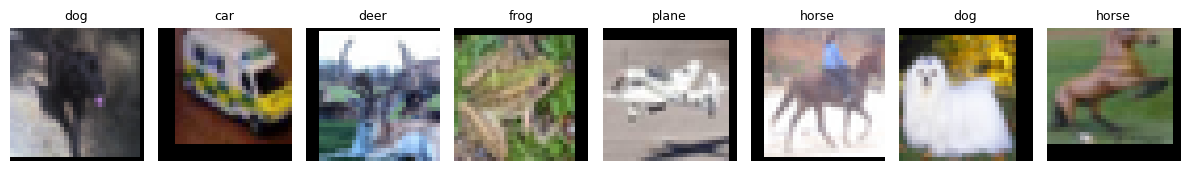

In [5]:
# CIFAR-10 class names (index order matters)
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

def unnormalize(img):
    return img * STD + MEAN

def show_images(loader, num_images=8):
    images, labels = next(iter(loader))  # grab one batch
    images, labels = images[:num_images], labels[:num_images]

    fig, axes = plt.subplots(1, num_images, figsize=(num_images * 1.5, 2))
    for i, ax in enumerate(axes):
        img = unnormalize(images[i]).permute(1, 2, 0).clamp(0, 1)  # CHW -> HWC
        ax.imshow(img.numpy())
        ax.set_title(classes[labels[i]], fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_images(train_loader, num_images=8)

##Model

In [6]:
def _init_weights(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)


class ShortcutA(nn.Module):
    '''
    Parameter-free identity shortcut
    Subsamples spatially with stride, then zero-pads the channel dimension.
    '''
    def __init__(self, in_channels, out_channels, stride):
        super().__init__()
        self.stride = stride
        self.pad_channels = out_channels - in_channels

    def forward(self, x):
        if self.stride != 1:
            x = x[:, :, ::self.stride, ::self.stride]  # spatial subsample, TRY MaxPool/AvgPool!
        if self.pad_channels > 0:
            # (W_left, W_right, H_top, H_bottom, C_front, C_back)
            x = F.pad(x, (0, 0, 0, 0, 0, self.pad_channels))
        return x


class ResidualBlock(nn.Module):
    '''
    Residual block of 2 conv layers with BatchNorm and ReLU for each layer
    and a skip connection

    bias ignored by batchnorm => False
    '''
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                                stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                                padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        # Projection shortcut, only if shape changes
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            #Option A
            self.shortcut = ShortcutA(in_channels, out_channels, stride)

            '''
            #Option B
            self.shortcut = nn.Sequential(
                    nn.Conv2d(in_channels, out_channels,
                              kernel_size=1,stride=stride,
                              bias=False),
                    nn.BatchNorm2d(out_channels)
                )
            '''

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        out += identity
        out = self.relu(out)

        return out



class DeepNN(nn.Module):
    '''
    ResNet-32
    5 blocks, 32 layers total
    '''
    def __init__(self):
        super(DeepNN, self).__init__()
        self.features = nn.Sequential(
            #Stage 1
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            #Stage 2
            ResidualBlock(16, 16),
            ResidualBlock(16, 16),
            ResidualBlock(16, 16),
            ResidualBlock(16, 16),
            ResidualBlock(16, 16),
            #Stage 3
            ResidualBlock(16, 32, stride=2),
            ResidualBlock(32, 32),
            ResidualBlock(32, 32),
            ResidualBlock(32, 32),
            ResidualBlock(32, 32),
            #Stage 4
            ResidualBlock(32, 64, stride=2),
            ResidualBlock(64, 64),
            ResidualBlock(64, 64),
            ResidualBlock(64, 64),
            ResidualBlock(64, 64),
            #stage 5 (classifier)
            nn.AvgPool2d(8, stride=1),
            #nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(64, 10)
            )
        self.apply(_init_weights)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return x

##Training

In [7]:
def train_step(model, batch, optimizer, criterion, scheduler):
    model.train()
    inputs, labels = batch
    inputs, labels = inputs.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    scheduler.step()

    correct = outputs.argmax(1).eq(labels).sum().item()

    '''
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    '''
    return loss.item(), correct, labels.size(0)
    #return running_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            #_, predicted = outputs.max(1)
            #correct += predicted.eq(labels).sum().item()
            correct += outputs.argmax(1).eq(labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

def infinite(loader):
    while True:
        for batch in loader:
            yield batch


In [8]:
def save_checkpoint(path, model, optimizer, scheduler, iteration):
    tmp = path + '.tmp'
    torch.save({
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'iteration': iteration,
    }, tmp)
    os.replace(tmp, path)

def load_checkpoint(path, model, optimizer, scheduler):
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint['model'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    scheduler.load_state_dict(checkpoint['scheduler'])
    return checkpoint['iteration'] + 1   # next iteration to run

In [9]:
model = DeepNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[32000, 48000], gamma=0.1)

max_iters = 64000
eval_per = 1000
start_iter = 0

checkpoint_dir = '/content/drive/MyDrive/resnet32_checkpoint'
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = f'{checkpoint_dir}/last.pt'

trained_dir = '/content/drive/MyDrive/resnet32_trained'
os.makedirs(checkpoint_dir, exist_ok=True)
trained_path = f'{trained_dir}/resnet-32-93.pt' #change accordingly

if os.path.exists(trained_path):
    start_iter = load_checkpoint(trained_path, model, optimizer, scheduler)
    print(f"Trained model found! ({start_iter} / {max_iters})")
elif os.path.exists(checkpoint_path):
    start_iter = load_checkpoint(checkpoint_path, model, optimizer, scheduler)
    print(f"Checkpoint {checkpoint_path} found, resumed from iteration {start_iter}")
else:
    print("No checkpoint found, training from scratch")

train_iter = infinite(train_loader)
#train_iter = cycle(train_loader)
run_loss, run_correct, run_total = 0.0, 0, 0

### Main training loop ###
for iteration in range(start_iter, max_iters):
    batch = next(train_iter)
    loss, correct, n = train_step(model, batch, optimizer, criterion, scheduler)
    run_loss += loss * n
    run_correct += correct
    run_total += n

    if (iteration + 1) % eval_per == 0:
        test_loss, test_acc = evaluate(model, test_loader, criterion)
        print(f"iter {iteration}/{max_iters}, "
                f"lr {scheduler.get_last_lr()[0]:.4f}, "
                f"train loss: {run_loss/run_total:.4f}, "
                f"train acc: {run_correct/run_total:.4f}, "
                f"test loss: {test_loss:.4f},"
                f"test acc {test_acc:.4f}")
        #run_loss, run_correct, run_total = 0.0, 0, 0
        save_checkpoint(checkpoint_path, model, optimizer, scheduler, iteration)
    if iteration + 1 == max_iters:
        timestamp = dt.datetime.now(ZoneInfo('Europe/Budapest')).strftime('%y%m%d_%H%M')
        trained_path = f'{trained_dir}/resnet32_{timestamp}'
        torch.save(model.state_dict(), trained_path)


Trained model found! (64000 / 64000)


Copied training logs:

```
iter 999/64000, lr 0.1000, train loss: 1.4859, train acc: 0.4566, test loss: 1.1050,test acc 0.6080
iter 1999/64000, lr 0.1000, train loss: 0.8082, train acc: 0.7161, test loss: 0.6813,test acc 0.7694
iter 2999/64000, lr 0.1000, train loss: 0.5879, train acc: 0.7964, test loss: 0.6342,test acc 0.7891
iter 3999/64000, lr 0.1000, train loss: 0.4891, train acc: 0.8303, test loss: 0.5533,test acc 0.8178
iter 4999/64000, lr 0.1000, train loss: 0.4321, train acc: 0.8504, test loss: 0.6298,test acc 0.7851
iter 5999/64000, lr 0.1000, train loss: 0.3887, train acc: 0.8662, test loss: 0.5706,test acc 0.8123
iter 6999/64000, lr 0.1000, train loss: 0.3611, train acc: 0.8758, test loss: 0.5926,test acc 0.8116
iter 7999/64000, lr 0.1000, train loss: 0.3394, train acc: 0.8823, test loss: 0.4751,test acc 0.8442
iter 8999/64000, lr 0.1000, train loss: 0.3174, train acc: 0.8902, test loss: 0.7329,test acc 0.7965
iter 9999/64000, lr 0.1000, train loss: 0.3000, train acc: 0.8961, test loss: 0.4923,test acc 0.8516
iter 10999/64000, lr 0.1000, train loss: 0.2871, train acc: 0.8993, test loss: 0.5067,test acc 0.8483
iter 11999/64000, lr 0.1000, train loss: 0.2748, train acc: 0.9044, test loss: 0.4653,test acc 0.8568
iter 12999/64000, lr 0.1000, train loss: 0.2659, train acc: 0.9082, test loss: 0.6029,test acc 0.8242
iter 13999/64000, lr 0.1000, train loss: 0.2587, train acc: 0.9097, test loss: 0.4480,test acc 0.8629
iter 14999/64000, lr 0.1000, train loss: 0.2513, train acc: 0.9118, test loss: 0.4050,test acc 0.8762
iter 15999/64000, lr 0.1000, train loss: 0.2444, train acc: 0.9145, test loss: 0.5154,test acc 0.8445
iter 16999/64000, lr 0.1000, train loss: 0.2357, train acc: 0.9172, test loss: 0.4553,test acc 0.8649
iter 17999/64000, lr 0.1000, train loss: 0.2342, train acc: 0.9183, test loss: 0.4876,test acc 0.8509
iter 18999/64000, lr 0.1000, train loss: 0.2251, train acc: 0.9209, test loss: 0.4684,test acc 0.8593
iter 19999/64000, lr 0.1000, train loss: 0.2263, train acc: 0.9207, test loss: 0.4517,test acc 0.8654
iter 20999/64000, lr 0.1000, train loss: 0.2157, train acc: 0.9244, test loss: 0.4483,test acc 0.8695
iter 21999/64000, lr 0.1000, train loss: 0.2147, train acc: 0.9249, test loss: 0.3779,test acc 0.8799
iter 22999/64000, lr 0.1000, train loss: 0.2130, train acc: 0.9244, test loss: 0.4800,test acc 0.8550
iter 23999/64000, lr 0.1000, train loss: 0.2082, train acc: 0.9266, test loss: 0.4206,test acc 0.8699
iter 24999/64000, lr 0.1000, train loss: 0.2081, train acc: 0.9271, test loss: 0.5493,test acc 0.8376
iter 25999/64000, lr 0.1000, train loss: 0.2012, train acc: 0.9299, test loss: 0.4938,test acc 0.8616
iter 26999/64000, lr 0.1000, train loss: 0.2032, train acc: 0.9288, test loss: 0.4176,test acc 0.8801
iter 27999/64000, lr 0.1000, train loss: 0.1960, train acc: 0.9313, test loss: 0.4695,test acc 0.8674
iter 28999/64000, lr 0.1000, train loss: 0.1970, train acc: 0.9313, test loss: 0.3965,test acc 0.8816
iter 29999/64000, lr 0.1000, train loss: 0.1956, train acc: 0.9309, test loss: 0.4797,test acc 0.8644
iter 30999/64000, lr 0.1000, train loss: 0.1924, train acc: 0.9321, test loss: 0.3531,test acc 0.8906
iter 31999/64000, lr 0.0100, train loss: 0.1902, train acc: 0.9326, test loss: 0.5200,test acc 0.8513
iter 32999/64000, lr 0.0100, train loss: 0.0923, train acc: 0.9691, test loss: 0.2600,test acc 0.9222
iter 33999/64000, lr 0.0100, train loss: 0.0620, train acc: 0.9798, test loss: 0.2663,test acc 0.9224
iter 34999/64000, lr 0.0100, train loss: 0.0508, train acc: 0.9838, test loss: 0.2767,test acc 0.9226
iter 35999/64000, lr 0.0100, train loss: 0.0450, train acc: 0.9855, test loss: 0.2795,test acc 0.9244
iter 36999/64000, lr 0.0100, train loss: 0.0381, train acc: 0.9878, test loss: 0.2865,test acc 0.9258
iter 37999/64000, lr 0.0100, train loss: 0.0343, train acc: 0.9894, test loss: 0.3009,test acc 0.9234
iter 38999/64000, lr 0.0100, train loss: 0.0299, train acc: 0.9906, test loss: 0.3057,test acc 0.9245
iter 39999/64000, lr 0.0100, train loss: 0.0275, train acc: 0.9915, test loss: 0.3059,test acc 0.9249
iter 40999/64000, lr 0.0100, train loss: 0.0261, train acc: 0.9920, test loss: 0.3126,test acc 0.9245
iter 41999/64000, lr 0.0100, train loss: 0.0238, train acc: 0.9924, test loss: 0.3234,test acc 0.9238
iter 42999/64000, lr 0.0100, train loss: 0.0221, train acc: 0.9934, test loss: 0.3214,test acc 0.9234
iter 43999/64000, lr 0.0100, train loss: 0.0205, train acc: 0.9940, test loss: 0.3275,test acc 0.9222
iter 44999/64000, lr 0.0100, train loss: 0.0196, train acc: 0.9939, test loss: 0.3282,test acc 0.9223
iter 45999/64000, lr 0.0100, train loss: 0.0182, train acc: 0.9943, test loss: 0.3352,test acc 0.9223
iter 46999/64000, lr 0.0100, train loss: 0.0168, train acc: 0.9951, test loss: 0.3334,test acc 0.9242
iter 47999/64000, lr 0.0010, train loss: 0.0164, train acc: 0.9954, test loss: 0.3491,test acc 0.9222
iter 48999/64000, lr 0.0010, train loss: 0.0127, train acc: 0.9967, test loss: 0.3355,test acc 0.9244
iter 49999/64000, lr 0.0010, train loss: 0.0123, train acc: 0.9967, test loss: 0.3360,test acc 0.9248
iter 50999/64000, lr 0.0010, train loss: 0.0110, train acc: 0.9971, test loss: 0.3369,test acc 0.9246
iter 51999/64000, lr 0.0010, train loss: 0.0109, train acc: 0.9972, test loss: 0.3351,test acc 0.9257
iter 52999/64000, lr 0.0010, train loss: 0.0111, train acc: 0.9973, test loss: 0.3341,test acc 0.9246
iter 53999/64000, lr 0.0010, train loss: 0.0104, train acc: 0.9976, test loss: 0.3350,test acc 0.9253
iter 54999/64000, lr 0.0010, train loss: 0.0100, train acc: 0.9979, test loss: 0.3380,test acc 0.9238
iter 55999/64000, lr 0.0010, train loss: 0.0102, train acc: 0.9975, test loss: 0.3379,test acc 0.9257
iter 56999/64000, lr 0.0010, train loss: 0.0099, train acc: 0.9976, test loss: 0.3410,test acc 0.9248
iter 57999/64000, lr 0.0010, train loss: 0.0100, train acc: 0.9974, test loss: 0.3385,test acc 0.9245
iter 58999/64000, lr 0.0010, train loss: 0.0101, train acc: 0.9974, test loss: 0.3390,test acc 0.9246
iter 59999/64000, lr 0.0010, train loss: 0.0094, train acc: 0.9978, test loss: 0.3381,test acc 0.9254
iter 60999/64000, lr 0.0010, train loss: 0.0094, train acc: 0.9978, test loss: 0.3412,test acc 0.9253
iter 61999/64000, lr 0.0010, train loss: 0.0095, train acc: 0.9978, test loss: 0.3417,test acc 0.9247
iter 62999/64000, lr 0.0010, train loss: 0.0089, train acc: 0.9978, test loss: 0.3414,test acc 0.9256
iter 63999/64000, lr 0.0010, train loss: 0.0092, train acc: 0.9979, test loss: 0.3404,test acc 0.9252
```



In [14]:
######## DELETE CHECKPOINT ########
#if os.path.exists(checkpoint_path):
#    os.remove(checkpoint_path)

#2. Pruning

In [19]:
model_path = f'{trained_dir}/resnet-32-93.pt'
#model_path = checkpoint_path
params = torch.load(model_path, map_location='cpu', weights_only=True)

def model_get_parameters(model, params):
    model_to_prune = copy.deepcopy(model)

    model_to_prune.load_state_dict(params['model'])
    model_to_prune.eval()

    first_l = model_to_prune.features[0]
    final_l = model_to_prune.features[-1]

    parameters_to_prune = [
        (m, "weight")
        for m in model_to_prune.modules()
        if isinstance(m, (nn.Conv2d, nn.Linear)) and m is not first_l and m is not final_l
    ]
    return parameters_to_prune, model_to_prune

In [20]:
@torch.no_grad()
def evaluate(model, loader, device=device):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        correct += (model(x).argmax(dim=1) == y).sum().item()
        total += y.size(0)
    return correct / total

L1 Unstructured

In [21]:
prune_rates = [x / 100.0 for x in range(0, 100, 5)]

performances = []
for rate in prune_rates:
    parameters_to_prune, model_to_prune = model_get_parameters(model, params)

    prune.global_unstructured(
        parameters_to_prune,
        pruning_method=prune.L1Unstructured,
        amount=rate,
    )
    performance = evaluate(model_to_prune, test_loader)
    performances.append(performance)
    print(rate, ' || ', performance)

0.0  ||  0.9252
0.05  ||  0.925
0.1  ||  0.9249
0.15  ||  0.9248
0.2  ||  0.9251
0.25  ||  0.9241
0.3  ||  0.9239
0.35  ||  0.921
0.4  ||  0.9182
0.45  ||  0.9103
0.5  ||  0.9021
0.55  ||  0.8981
0.6  ||  0.8666
0.65  ||  0.8112
0.7  ||  0.7052
0.75  ||  0.5037
0.8  ||  0.2982
0.85  ||  0.1595
0.9  ||  0.1393
0.95  ||  0.1


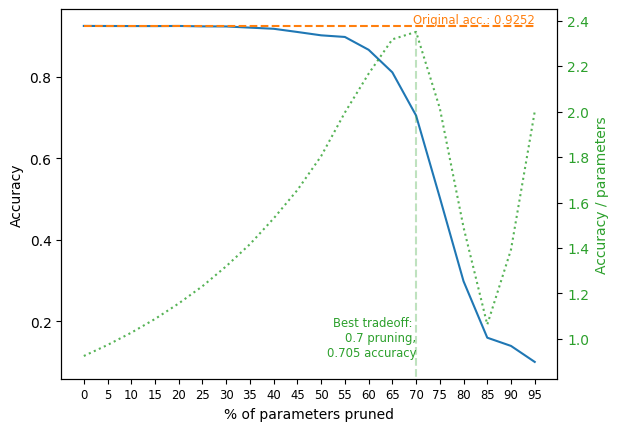

In [172]:
def visualize_prune(prune_rates=prune_rates, performances=performances, tradeoff_min_acc=0.6):
    ratio = []
    for i in range(len(prune_rates)):
        if prune_rates[i] != 1:
            r = performances[i] / (1.0 - prune_rates[i])
            ratio.append(r)
            if r == max(ratio) and performances[i] >= tradeoff_min_acc: # minimum is checked to ignore high ratios at too low accuracies
                best_r = r
        else:
            prune_rates.pop(i)
            performances.pop(i)
            print(prune_rates, performances)

    fig, ax = plt.subplots()
    ax.plot(prune_rates, performances)

    ax.plot(prune_rates, [performances[0] for x in performances], ls='dashed')

    ax.text(prune_rates[-1], performances[0],
            f"Original acc.: {performances[0]}",
            va="bottom", ha="right", size='small', c='C1')

    plt.plot(performances[0])
    plt.ylabel('Accuracy')
    plt.xlabel('% of parameters pruned')
    plt.xticks(prune_rates, (int(x * 100) for x in prune_rates), rotation=0, size='small')




    ax2 = ax.twinx()
    ax2.plot(prune_rates, ratio, color='C2', ls=':', alpha=0.8)
    ax2.set_ylabel('Accuracy / parameters', color='C2')
    ax2.tick_params(axis='y', labelcolor='C2')

    min_r, max_r = min(ratio), max(ratio)
    best_r_index = ratio.index(best_r)
    ax2.vlines(prune_rates[best_r_index], 0, max_r, color='C2', ls='--', alpha=0.3)
    ax2.text(prune_rates[best_r_index], min_r,
             f"Best tradeoff: \n{prune_rates[best_r_index]} pruning,"
             f"\n{performances[best_r_index]:.3f} accuracy",
             ha='right', color = 'C2', size='small')
    plt.ylim(min_r - 0.1, max_r + 0.1)

    plt.show()
    fig.tight_layout()

# random lists for testing
rates_1 = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
acc_1   = [0.8810, 0.8720, 0.8605, 0.8450, 0.8240, 0.7960, 0.7580, 0.7050, 0.6280, 0.5100, 0.4940]
rates_2 = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.6, 0.7, 0.8, 0.9]
acc_2   = [0.9710, 0.9722, 0.9731, 0.9728, 0.9715, 0.9690, 0.9602, 0.9310, 0.8420, 0.6150, 0.3870, 0.2210, 0.1480, 0.1050, 0.1000]
rates_3 = [0.0, 0.04, 0.08, 0.12, 0.16, 0.2, 0.24, 0.28, 0.32, 0.36, 0.4, 0.44, 0.48,
           0.52, 0.56, 0.6, 0.64, 0.68, 0.72, 0.76, 0.8, 0.84, 0.88, 0.92, 0.96]
acc_3   = [0.7634, 0.7651, 0.7620, 0.7668, 0.7642, 0.7629, 0.7655, 0.7610, 0.7598, 0.7571, 0.7602, 0.7549, 0.7513,
           0.7480, 0.7392, 0.7301, 0.7144, 0.6870, 0.6422, 0.5735, 0.4801, 0.3622, 0.2415, 0.1380, 0.1012]
rates_4 = [0.0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.99]
acc_4   = [0.9440, 0.9395, 0.9310, 0.9120, 0.8650, 0.7890, 0.6540, 0.3120]

visualize_prune()